In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
df_train.shape, df_test.shape

((1460, 81), (1459, 80))

In [2]:
df_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Посмотрим на кореляцию с районом

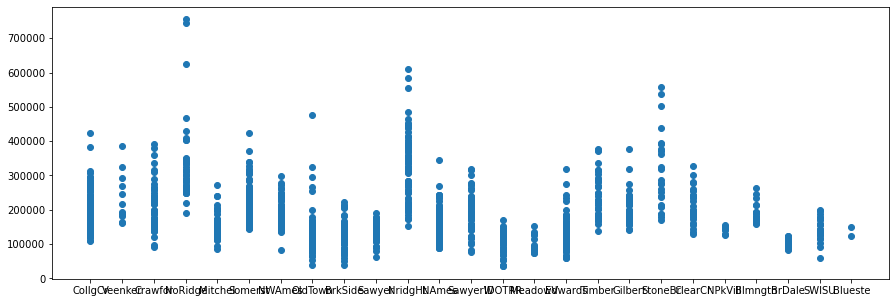

In [4]:

fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(df_train['Neighborhood'], df_train['SalePrice'])

Логарифмируем цены

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='SalePrice', ylabel='Density'>

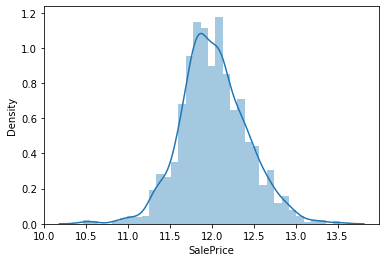

In [5]:
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])
sns.distplot(df_train['SalePrice'])

<AxesSubplot:>

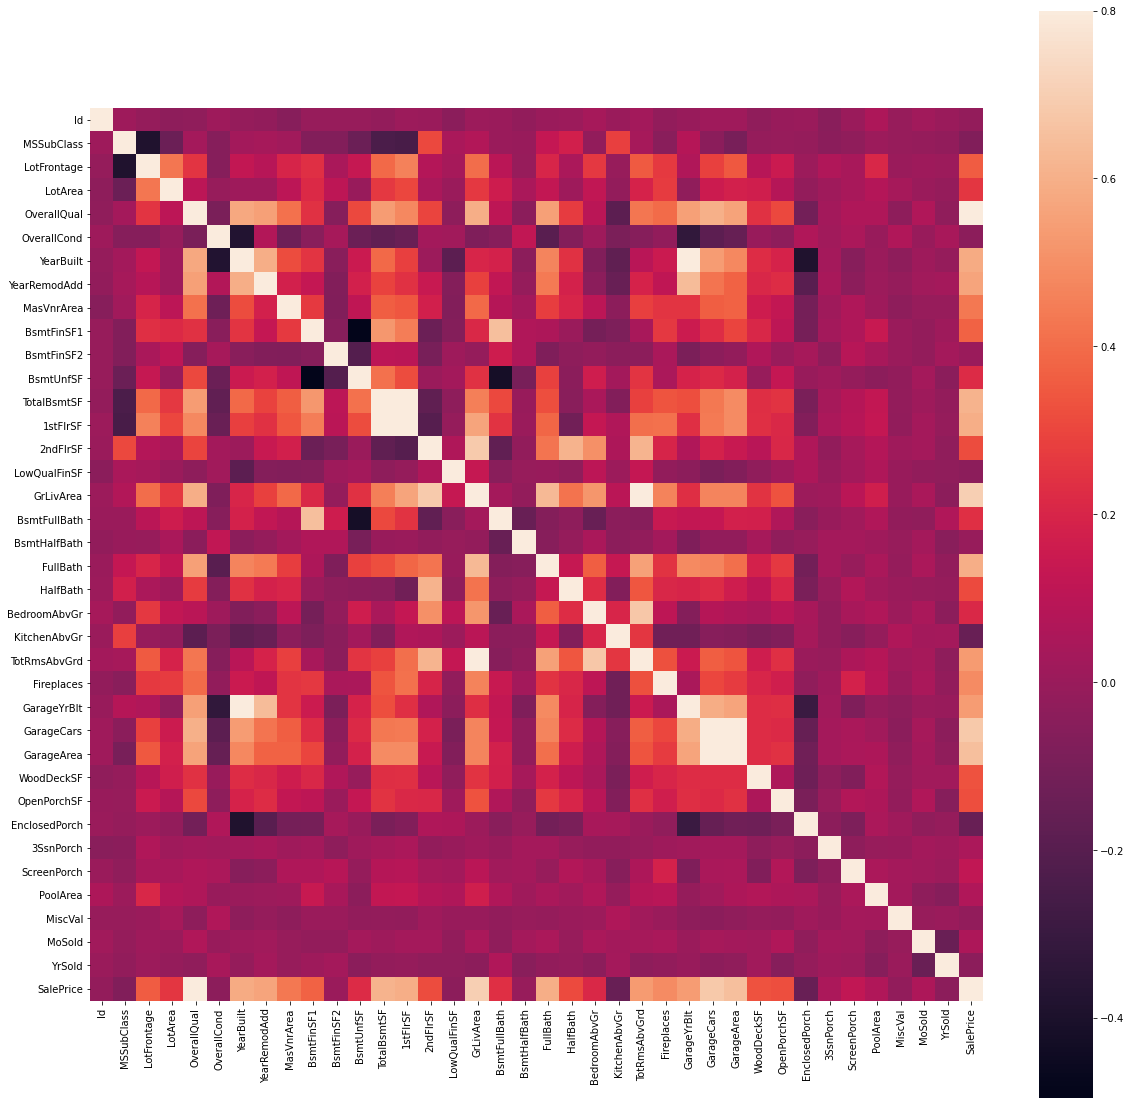

In [6]:
corrmat = df_train.corr()

f,ax = plt.subplots(figsize = (20,20))
sns.heatmap(corrmat, vmax =.8, square = True)

In [7]:
cols = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index
cols

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

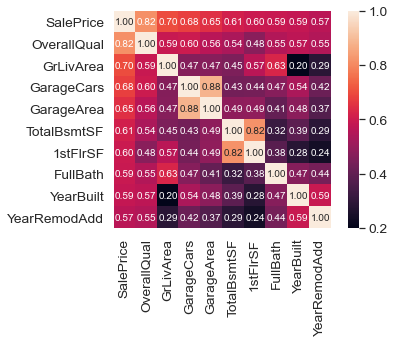

In [8]:
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale = 1.25)
hm = sns.heatmap(cm, cbar = True, annot = True, square= True, 
                 fmt = '.2f', annot_kws = {'size':10},
                 yticklabels= cols.values, xticklabels= cols.values)

In [9]:
X = df_train.iloc[:1000]


1. Чистим GrLivArea

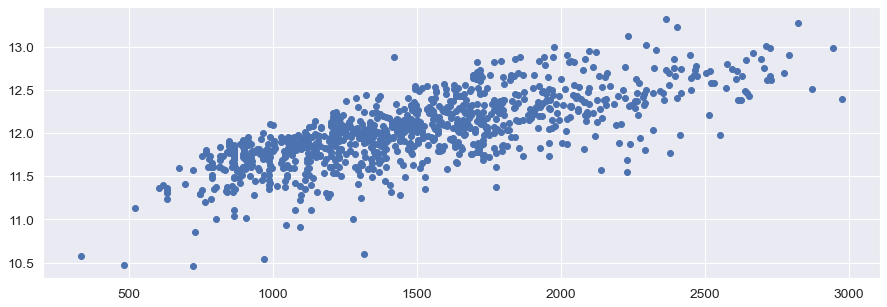

In [10]:
X = X.drop(X[X['GrLivArea']>3000].index)
X = X.reset_index(drop = True)
fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(X['GrLivArea'], X['SalePrice'])

2. Чистим TotalBSMTSF

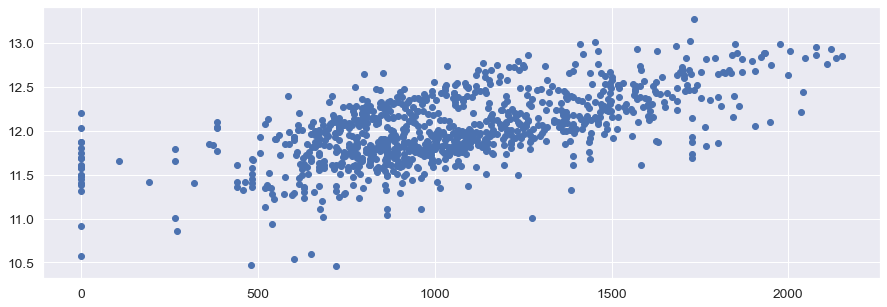

In [11]:
X = X.drop(X[X['TotalBsmtSF']>2200].index)
X = X.reset_index(drop = True)
fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(X['TotalBsmtSF'], X['SalePrice'])

3. Чистим GarageArea

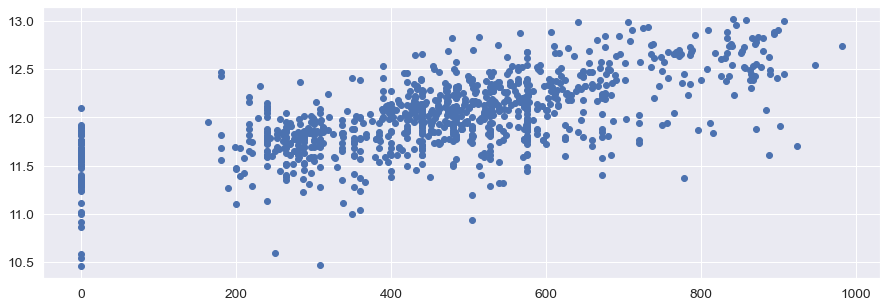

In [12]:
X = X.drop(X[X['GarageArea']>1000].index)
X = X.reset_index(drop = True)
fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(X['GarageArea'], X['SalePrice'])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='GarageArea', ylabel='Density'>

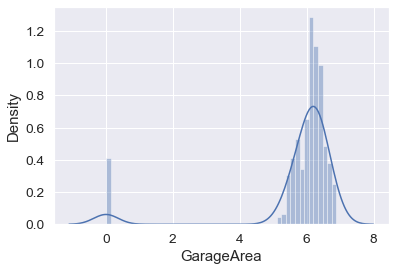

In [13]:
sns.distplot(np.log1p(X['GarageArea']))

4. чистим OverQual

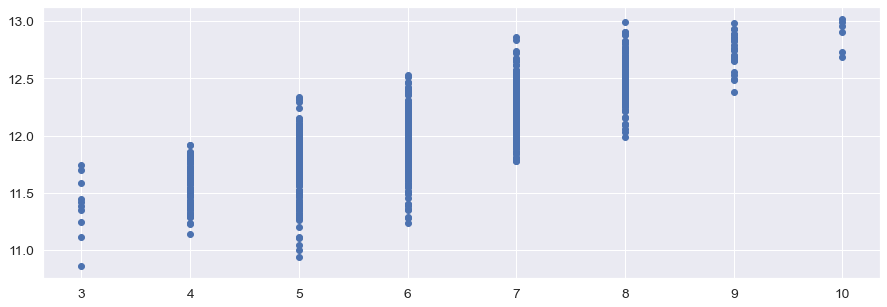

In [14]:
X = X.drop(X[X['OverallQual']<3].index)
X = X.reset_index(drop = True)
X = X.drop(X[(X['OverallQual'] == 4) & (X["SalePrice"] > 12)].index).reset_index(drop=True)
X = X.drop(X[(X['OverallQual'] == 4) & (X["SalePrice"] < 11)].index).reset_index(drop=True)
X = X.drop(X[(X['OverallQual'] == 8) & (X["SalePrice"] > 13)].index).reset_index(drop=True)
X = X.drop(X[(X['OverallQual'] == 9) & (X["SalePrice"] > 13)].index).reset_index(drop=True)
X = X.drop(X[(X['OverallQual'] == 7) & (X["SalePrice"] < 11.75)].index).reset_index(drop=True)
X = X.drop(X[(X['OverallQual'] == 3) & (X["SalePrice"] < 10.75)].index).reset_index(drop=True)
fig, ax = plt.subplots(figsize = (15,5))
ax.scatter(X['OverallQual'], X['SalePrice'])

5. Добавим районы

<AxesSubplot:>

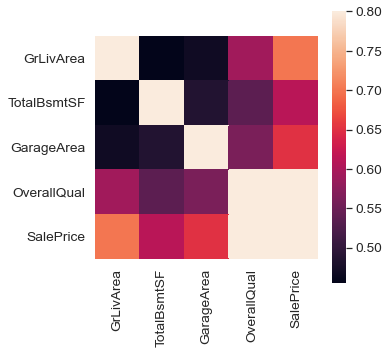

In [15]:
corrmat = df_train[['GrLivArea', 'TotalBsmtSF', 'GarageArea','OverallQual', 'SalePrice']].corr()
f,ax = plt.subplots(figsize = (5,5))
sns.heatmap(corrmat, vmax =.8, square = True)

In [16]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error



In [17]:
reg = linear_model.LinearRegression()
Y = X['SalePrice']
x = X[['GrLivArea', 'TotalBsmtSF', 'GarageArea','OverallQual']]
reg.fit(x, Y)

LinearRegression()

In [18]:
score = np.sqrt(mean_squared_error(df_train.iloc[1001:]['SalePrice'], reg.predict(df_train.iloc[1001:][['GrLivArea', 'TotalBsmtSF', 'GarageArea','OverallQual']])))
print(score)

0.21540011279481028


In [19]:
reg_ridge = linear_model.Ridge(alpha=10)
reg_ridge.fit(x,Y)
score = np.sqrt(mean_squared_error(df_train.iloc[1001:]['SalePrice'], reg_ridge.predict(df_train.iloc[1001:][['GrLivArea', 'TotalBsmtSF', 'GarageArea','OverallQual']])))
print(score)

0.21574963114665344


In [20]:
reg_lasso = linear_model.Lasso(alpha=1)
reg_lasso.fit(x,Y)
score = np.sqrt(mean_squared_error(df_train.iloc[1001:]['SalePrice'], reg_lasso.predict(df_train.iloc[1001:][['GrLivArea', 'TotalBsmtSF', 'GarageArea','OverallQual']])))
print(score)

0.27217431820150584
